# 04 - Interactive Demo

Interactive exploration of zero-background KdV reflectionless potentials generated by the stable Prins-Wahls Crum algorithm.

In [1]:
using Pkg
Pkg.activate("..")

using Revise
includet("../src/KdVCrumProject.jl")
using .KdVCrumProject

using Plots, LaTeXStrings, Interact

  Activating project at `~/Desktop/ResearchProjects/Dilute Gases/KdVCrumProject`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


The sliders control the number of eigenvalues, the eigenvalue spacing, the sampled x-domain, and the scale of the target norming constants.

In [2]:
function interactive_spectrum(N, spacing, beta_scale)
    kappa = uniform_kappa(N; start=spacing, spacing=spacing)
    signs = alternating_norming_constants(N)
    weights = N == 1 ? [1.0] : exp.(range(-beta_scale, beta_scale; length=N))
    beta = signs .* weights
    return kappa, beta
end

function demo_plot(N, spacing, L, beta_scale)
    x = collect(range(-L, L; length=2001))
    kappa, beta = interactive_spectrum(N, spacing, beta_scale)
    q = crum_transform(x, kappa, beta)
    E1, E2 = conserved_errors(x, q, kappa)

    title = "N=$N, spacing=$(round(spacing; digits=3)), E1=$(round(E1; sigdigits=3)), E2=$(round(E2; sigdigits=3))"
    plot_potential(x, q; label=L"q_N(x)", title=title, legend=:topright)
end;

In [3]:
@manipulate for N in 1:50,
                spacing in 0.04:0.01:0.25,
                L in 15.0:5.0:120.0,
                beta_scale in 0.0:0.25:4.0
    demo_plot(N, spacing, L, beta_scale)
end

(div
  Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["N"], Dict{Symbol, Any}(:className => "interact ", :style => Dict{Any, Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol, Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol, Any}(:max => 50, :min => 1, :attributes => Dict{Any, Any}(:type => "range", Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}", "orient" => "horizontal"), :step => 1, :className => "slider slider is-fullwidth", :style => Dict{Any, Any}()))], Dict{Symbol, Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol, Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol, Any}(:className => "interact-flex-row-right"))], Dict{Symbol, Any}(:className => "interact-flex-row interact-widget")), Dict{String, Tuple{AbstractObservable, Union{Nothing, Bool}}}("changes" => (Observable(0), nothing), "index" => (Observable(25), nothing)), Set{String}(), nothing, Asset[Asset("js", "knockout", "/Users/fudong/.julia/packages/Knockout/HReiN/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/Users/fudong/.julia/packages/Knockout/HReiN/src/../assets/knockout_punches.js"), Asset("js", nothing, "/Users/fudong/.julia/packages/InteractBase/8TTmI/src/../assets/all.js"), Asset("css", nothing, "/Users/fudong/.julia/packages/InteractBase/8TTmI/src/../assets/style.css"), Asset("css", nothing, "/Users/fudong/.julia/packages/Interact/PENUy/src/../assets/bulma.min.css")], Dict{Any, Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")], "index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(32), Set{AbstractConnection}(), Base.GenericCondition(ReentrantLock())), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"1\",\"2\",\"3\",\"4\",\"5\",\"6\",\"7\",\"8\",\"9\",\"10\",\"11\",\"12\",\"13\",\"14\",\"15\",\"16\",\"17\",\"18\",\"19\",\"20\",\"21\",\"22\",\"23\",\"24\",\"25\",\"26\",\"27\",\"28\",\"29\",\"30\",\"31\",\"32\",\"33\",\"34\",\"35\",\"36\",\"37\",\"38\",\"39\",\"40\",\"41\",\"42\",\"43\",\"44\",\"45\",\"46\",\"47\",\"48\",\"49\",\"50\"],\"changes\":WebIO.getval({\"name\":\"changes\",\"scope\":\"11397377584552525645\",\"id\":\"2\",\"type\":\"observable\"}),\"index\":WebIO.getval({\"n

For notebook frontends where `Interact.jl` widgets are unavailable, use this plain function call as a fallback.

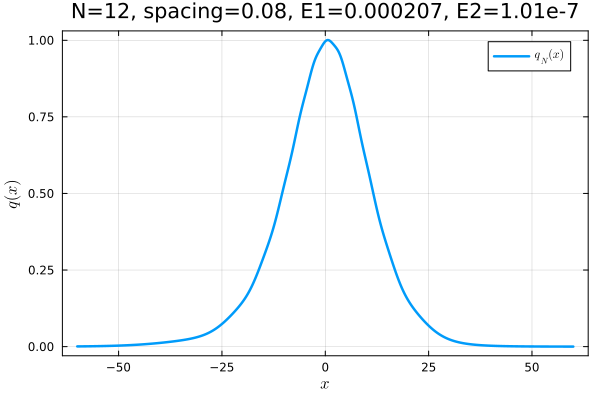

In [4]:
demo_plot(12, 0.08, 60.0, 1.0)